# Hands-On-Activity 7.2 | CNN Architectures from Scratch and Transfer Learning

Due to runtime limitations, the supplementary activity was conducted in a separate notebook.

## Supplementary Activity

1. Create a MobileNetV2 Network.

2. Train on the given dataset and reach at least 95% Accuracy. Do not use pre-trained weights.

3. Plot the accuracy for both Training and Validation. Include a confusion matrix, and a classification report (Precision, Recall , F1 score, Sensitivity) Plot the ROC AUC score result of the model

4. Interpret and evaluate the result of the model.

5. Import a pretrained MobileNetV2 Network, adjust the final layers to match the dataset. Must have pre-trained weights.

6. Fine tune on the given dataset, plot the same metrics in #3 and #4.

7. Compare the results of the trained network from scratch and fine-tuned network.

### Import Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
data_dir = '/content/drive/MyDrive/CPE313/hoa7.2/FastAI_ImageNet_v2'

# 3. Check it looks right
import os
print(os.listdir(data_dir))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['Validation.csv', 'Training.csv', 'training_composition.txt', 'validation_composition.txt', 'train', 'val']


In [ ]:
# Fix — rename extensions to lowercase
import pathlib

count = 0
for split in ['train', 'val']:
    for cls in os.listdir(f'{data_dir}/{split}'):
        cls_path = f'{data_dir}/{split}/{cls}'
        for f in pathlib.Path(cls_path).iterdir():
            if f.suffix == '.JPEG':
                f.rename(f.with_suffix('.jpeg'))
                count += 1

print(f"Renamed {count} files")

Renamed 0 files


In [ ]:
import torch
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_set = ImageFolder(root=f'{data_dir}/train', transform=transform_train)
val_set   = ImageFolder(root=f'{data_dir}/val',   transform=transform_val)
class_names = train_set.classes
print(f"Classes: {class_names}")

train_loader = DataLoader(train_set, batch_size=20, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_set,   batch_size=20, shuffle=False, num_workers=2)

print(f"Training samples (full): {len(train_set)}")
print(f"Validation samples (full): {len(val_set)}")

images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")

Classes: ['cassette_player', 'chain_saw', 'church', 'english_springer', 'french_horn', 'garbage_truck', 'gas_pump', 'golf_ball', 'parachute', 'tench']
Training samples (full): 9469
Validation samples (full): 3925
Batch shape: torch.Size([20, 3, 224, 224])


Same data augmentation techniques used as the Procedure.

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


### MobileNetV2 from Scratch

In [ ]:
import torch.nn as nn

# Depthwise Separable Conv Block
class ConvBNReLU(nn.Sequential):
    def __init__(self, in_ch, out_ch, kernel=3, stride=1, groups=1):
        padding = (kernel - 1) // 2
        super().__init__(
            nn.Conv2d(in_ch, out_ch, kernel, stride=stride,
                      padding=padding, groups=groups, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU6(inplace=True)
        )

# Inverted Residual Block (the core building block of MobileNetV2)
class InvertedResidual(nn.Module):
    def __init__(self, in_ch, out_ch, stride, expand_ratio):
        super().__init__()
        self.use_residual = (stride == 1 and in_ch == out_ch)
        hidden = int(round(in_ch * expand_ratio))

        layers = []
        if expand_ratio != 1:
            layers.append(ConvBNReLU(in_ch, hidden, kernel=1))  # pointwise expand
        layers += [
            ConvBNReLU(hidden, hidden, stride=stride, groups=hidden),  # depthwise
            nn.Conv2d(hidden, out_ch, 1, bias=False),                  # pointwise project
            nn.BatchNorm2d(out_ch),
        ]
        self.conv = nn.Sequential(*layers)

    def forward(self, x):
        return x + self.conv(x) if self.use_residual else self.conv(x)

# Full MobileNetV2
class MobileNetV2Scratch(nn.Module):
    # Each row: [expand_ratio, out_channels, num_blocks, stride]
    CFG = [
        [1,  16, 1, 1],
        [6,  24, 2, 2],
        [6,  32, 3, 2],
        [6,  64, 4, 2],
        [6,  96, 3, 1],
        [6, 160, 3, 2],
        [6, 320, 1, 1],
    ]

    def __init__(self, num_classes=10):
        super().__init__()

        # First conv layer
        self.features = [ConvBNReLU(3, 32, stride=2)]

        # Inverted residual blocks
        in_ch = 32
        for t, c, n, s in self.CFG:
            for i in range(n):
                stride = s if i == 0 else 1
                self.features.append(InvertedResidual(in_ch, c, stride, t))
                in_ch = c

        # Last conv layer
        self.features.append(ConvBNReLU(320, 1280, kernel=1))
        self.features = nn.Sequential(*self.features)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Dropout(0.3), #dropout
            nn.Linear(1280, num_classes),
        )

        self._initialize_weights()

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None: nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

model_scratch = MobileNetV2Scratch(num_classes=10).to(device)
print(f"Total parameters: {sum(p.numel() for p in model_scratch.parameters()):,}")

Total parameters: 2,236,682


### Show datset contents

Label indices: [3, 1, 5, 2, 1, 4, 9, 5]
Label names:   ['english_springer', 'chain_saw', 'garbage_truck', 'church', 'chain_saw', 'french_horn', 'tench', 'garbage_truck']


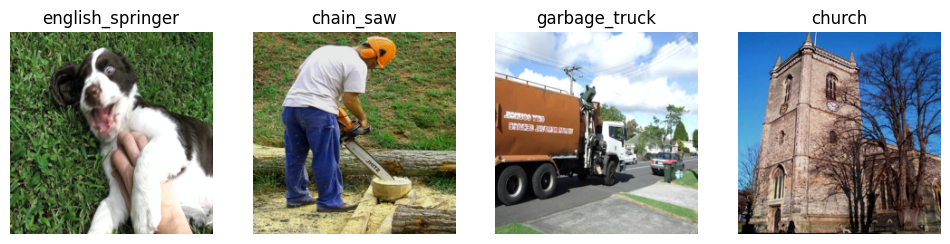

In [ ]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))
print(f"Label indices: {labels[:8].tolist()}")
print(f"Label names:   {[class_names[i] for i in labels[:8].tolist()]}")

# visually check a few images
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i, ax in enumerate(axes):
    img = images[i].permute(1, 2, 0).numpy()
    img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]  #unnormalize
    img = img.clip(0, 1)
    ax.imshow(img)
    ax.set_title(class_names[labels[i]])
    ax.axis('off')
plt.show()

### Train model

In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.amp import autocast, GradScaler

model_scratch = MobileNetV2Scratch(num_classes=10).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model_scratch.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='max', patience=2, factor=0.5)
scaler    = GradScaler('cuda')

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                epochs=50, early_stop_patience=10):
    history       = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    total_train   = len(train_loader.dataset)
    total_val     = len(val_loader.dataset)
    total_batches = len(train_loader)
    first_95      = None

    # Early stopping state
    best_val_acc     = 0.0
    patience_counter = 0

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1} -------------------------------")

        # Training
        model.train()
        train_loss, train_correct, total = 0, 0, 0

        for batch, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            with autocast('cuda'):
                outputs = model(images)
                loss    = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            train_loss    += loss.item() * images.size(0)
            train_correct += outputs.argmax(1).eq(labels).sum().item()
            total         += images.size(0)

            if (batch + 1) % (total_batches // 8) == 0 or total == total_train:
                print(f"  loss: {loss.item():.6f}  acc: {train_correct/total*100:.1f}%  [{total:>4}/{total_train}]")

        train_loss /= total_train
        train_acc   = train_correct / total_train
        print(f"Train:\n  Accuracy: {train_acc*100:.1f}%  |  Avg loss: {train_loss:.6f}")

        # ── Validation ──
        print("Validating...", end=' ', flush=True)
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0

        with torch.no_grad():
            for batch, (images, labels) in enumerate(val_loader):
                images, labels = images.to(device), labels.to(device)

                with autocast('cuda'):
                    outputs = model(images)
                    loss    = criterion(outputs, labels)

                val_loss    += loss.item() * images.size(0)
                val_correct += outputs.argmax(1).eq(labels).sum().item()
                val_total   += images.size(0)

                if (batch + 1) % 10 == 0 or val_total == total_val:
                    print(f"[{val_total}/{total_val}]", end=' ', flush=True)

        print()
        val_loss /= total_val
        val_acc   = val_correct / total_val

        scheduler.step(val_acc)

        print(f"Val:\n  Accuracy: {val_acc*100:.1f}%  |  Avg loss: {val_loss:.6f}")

        # 95% check
        if val_acc >= 0.95 and first_95 is None:
            first_95 = epoch + 1
            print(f"\nFirst reached 95% at epoch {first_95}! Continuing training...")

        # Early stopping check
        if val_acc > best_val_acc:
            best_val_acc     = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), 'mobilenetv2_scratch_best.pth')
            print(f"  ↑ New best val acc: {best_val_acc*100:.1f}%")
        else:
            patience_counter += 1
            print(f"  No improvement. Patience: {patience_counter}/{early_stop_patience}")
            if patience_counter >= early_stop_patience:
                print(f"Early stopping at epoch {epoch+1} — no improvement for {early_stop_patience} epochs")
                break

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

    if first_95:
        print(f"\nFirst hit 95% at epoch {first_95} | Best Val Acc: {best_val_acc*100:.1f}%")
    else:
        print(f"\n95% was never reached | Best Val Acc: {best_val_acc*100:.1f}%")

    return history



In [ ]:
history_scratch = train_model(
    model_scratch, train_loader, val_loader,
    criterion, optimizer, scheduler,
    epochs=67, early_stop_patience=5
)


Epoch 1 -------------------------------
  loss: 2.148292  acc: 15.8%  [1180/9469]
  loss: 2.013696  acc: 18.8%  [2360/9469]
  loss: 2.115888  acc: 20.2%  [3540/9469]
  loss: 2.194725  acc: 21.4%  [4720/9469]
  loss: 1.941108  acc: 23.0%  [5900/9469]
  loss: 2.112719  acc: 24.4%  [7080/9469]
  loss: 2.041788  acc: 26.0%  [8260/9469]
  loss: 1.841592  acc: 27.2%  [9440/9469]
  loss: 1.889250  acc: 27.3%  [9469/9469]
Train:
  Accuracy: 27.3%  |  Avg loss: 2.064298
Validating... [200/3925] [400/3925] [600/3925] [800/3925] [1000/3925] [1200/3925] [1400/3925] [1600/3925] [1800/3925] [2000/3925] [2200/3925] [2400/3925] [2600/3925] [2800/3925] [3000/3925] [3200/3925] [3400/3925] [3600/3925] [3800/3925] [3925/3925] 
Val:
  Accuracy: 37.1%  |  Avg loss: 1.889416
  ↑ New best val acc: 37.1%

Epoch 2 -------------------------------
  loss: 2.103319  acc: 35.2%  [1180/9469]
  loss: 1.876365  acc: 35.3%  [2360/9469]
  loss: 1.689827  acc: 37.0%  [3540/9469]
  loss: 1.576230  acc: 38.1%  [4720/9469]

#### Evaluation

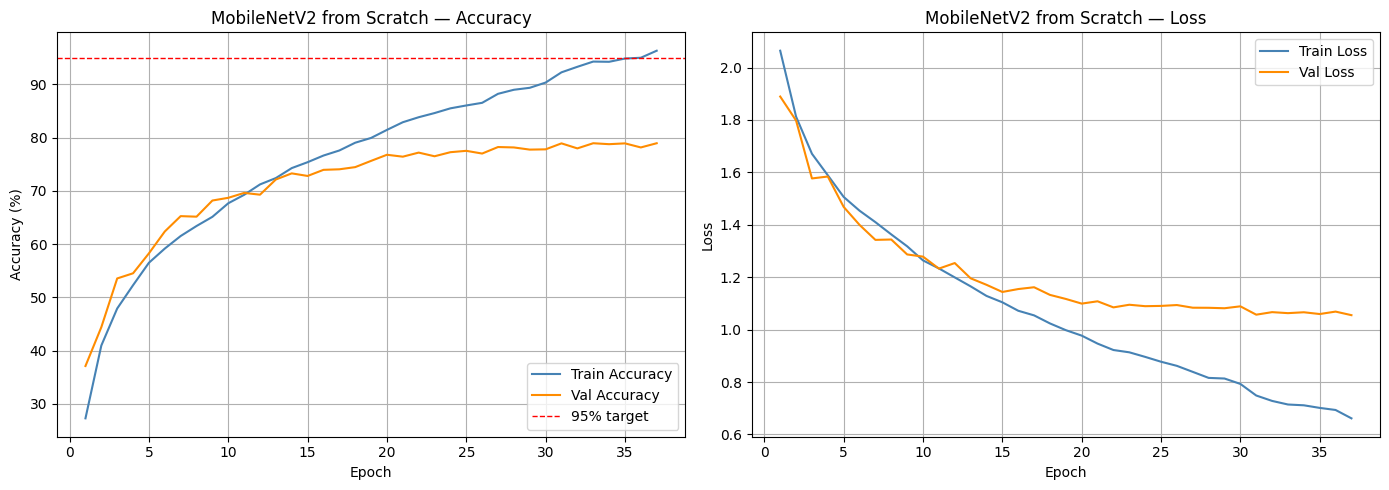

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history, title='MobileNetV2'):
    epochs = range(1, len(history['train_acc']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, [a*100 for a in history['train_acc']], label='Train Accuracy', color='steelblue')
    ax1.plot(epochs, [a*100 for a in history['val_acc']],   label='Val Accuracy',   color='darkorange')
    ax1.axhline(y=95, color='red', linestyle='--', linewidth=1, label='95% target')
    ax1.set_title(f'{title} — Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy (%)')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(epochs, history['train_loss'], label='Train Loss', color='steelblue')
    ax2.plot(epochs, history['val_loss'],   label='Val Loss',   color='darkorange')
    ax2.set_title(f'{title} — Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history_scratch, title='MobileNetV2 from Scratch')

Just like before, the model made from scratch starts to overfit at a certain level. After around 25-30 epochs, the model's performance starts to plateau, and early stopping helps save time by stopping the training once the training starts to feel the same for too long.

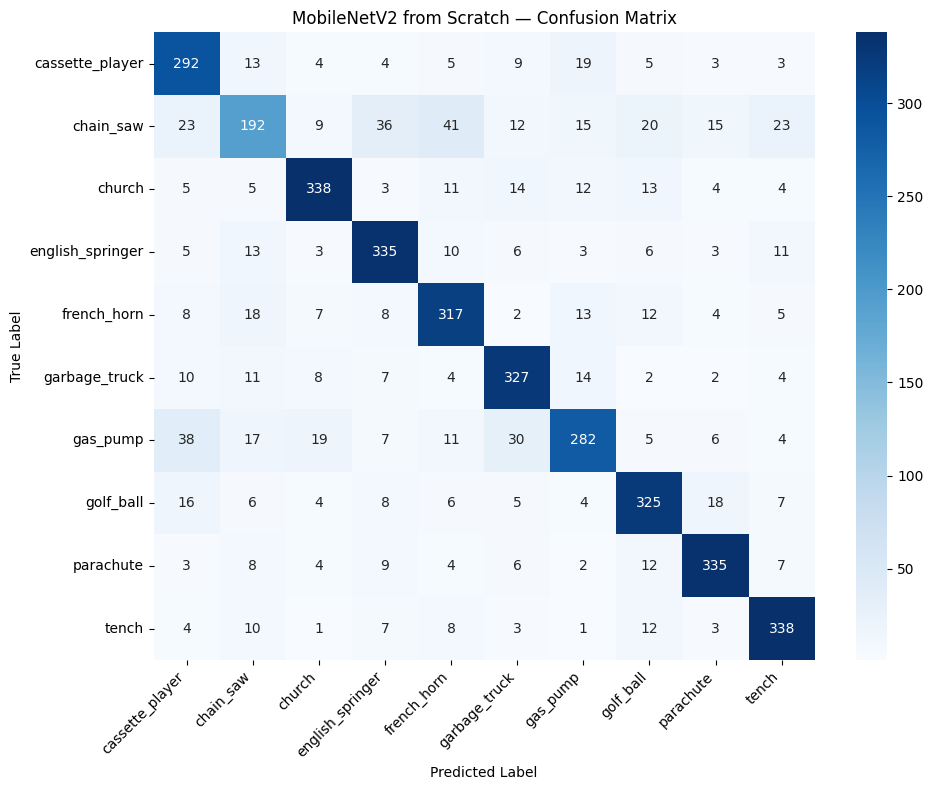


MobileNetV2 from Scratch — Classification Report

                  precision    recall  f1-score   support

 cassette_player       0.72      0.82      0.77       357
       chain_saw       0.66      0.50      0.57       386
          church       0.85      0.83      0.84       409
english_springer       0.79      0.85      0.82       395
     french_horn       0.76      0.80      0.78       394
   garbage_truck       0.79      0.84      0.81       389
        gas_pump       0.77      0.67      0.72       419
       golf_ball       0.79      0.81      0.80       399
       parachute       0.85      0.86      0.86       390
           tench       0.83      0.87      0.85       387

        accuracy                           0.78      3925
       macro avg       0.78      0.79      0.78      3925
    weighted avg       0.78      0.78      0.78      3925



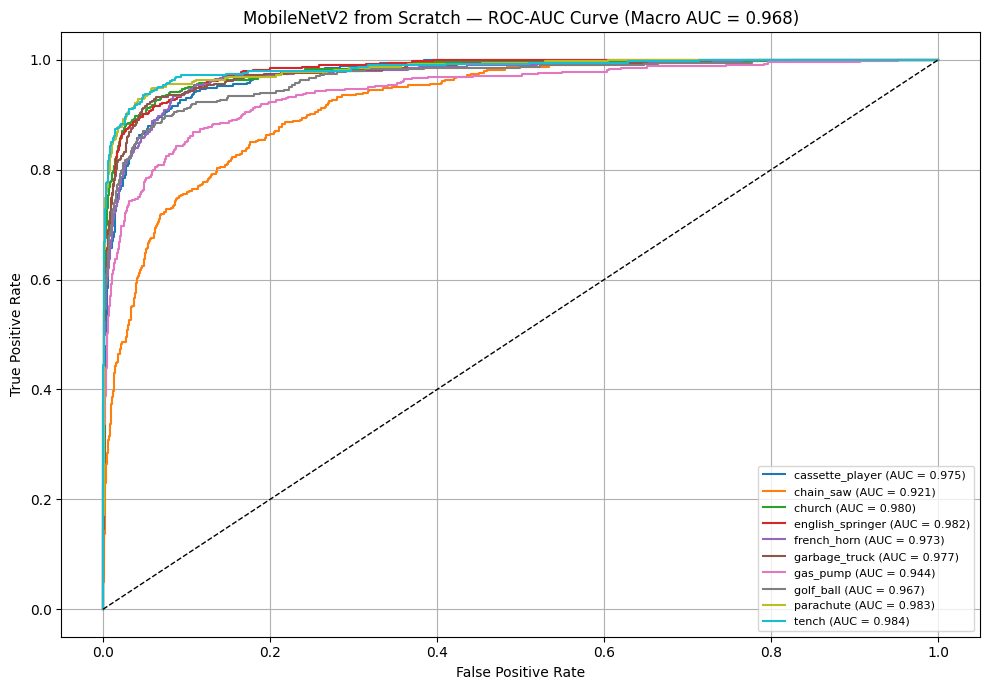

In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
from sklearn.preprocessing import label_binarize
import torch.nn.functional as F

def evaluate_model(model, val_loader, class_names, title='Model'):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            probs   = F.softmax(outputs, dim=1).cpu().numpy()
            preds   = outputs.argmax(1).cpu().numpy()

            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    all_labels = np.array(all_labels)
    all_preds  = np.array(all_preds)
    all_probs  = np.array(all_probs)

    # ── Confusion Matrix ──────────────────────────────────────────────────
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{title} — Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # ── Classification Report ─────────────────────────────────────────────
    print(f"\n{title} — Classification Report\n")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # ── ROC-AUC Curve ─────────────────────────────────────────────────────
    n_classes  = len(class_names)
    labels_bin = label_binarize(all_labels, classes=range(n_classes))

    plt.figure(figsize=(10, 7))
    for i, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(labels_bin[:, i], all_probs[:, i])
        auc = roc_auc_score(labels_bin[:, i], all_probs[:, i])
        plt.plot(fpr, tpr, label=f'{cls} (AUC = {auc:.3f})')

    macro_auc = roc_auc_score(labels_bin, all_probs, average='macro', multi_class='ovr')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
    plt.title(f'{title} — ROC-AUC Curve (Macro AUC = {macro_auc:.3f})')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right', fontsize=8)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return all_labels, all_preds, all_probs

labels_s, preds_s, probs_s = evaluate_model(
    model_scratch, val_loader, class_names, title='MobileNetV2 from Scratch'
)

The curve shows that while the accuracy is a below expectations, the model can still perfectly differentiate the classes between each other.

### Pretrained MobileNetV2

In [ ]:
import torchvision.models as models

# Load pretrained MobileNetV2
model_pretrained = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

# Freeze all feature extractor layers
for param in model_pretrained.features.parameters():
    param.requires_grad = False

# Replace the classifier head to match 10 classes
# MobileNetV2's classifier is model.classifier[1] (Linear 1280 → 1000)
model_pretrained.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(model_pretrained.last_channel, 10),
)

model_pretrained = model_pretrained.to(device)

# Only train the new classifier head
optimizer_pt = optim.Adam(model_pretrained.classifier.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler_pt = ReduceLROnPlateau(optimizer_pt, mode='max', patience=3, factor=0.5)

trainable = sum(p.numel() for p in model_pretrained.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_pretrained.parameters())
print(f"Trainable parameters: {trainable:,} / {total:,}")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 61.6MB/s]


Trainable parameters: 12,810 / 2,236,682


#### Finetuning


Epoch 1 -------------------------------
  loss: 1.811983  acc: 38.2%  [1180/9469]
  loss: 1.451641  acc: 56.9%  [2360/9469]
  loss: 1.309680  acc: 67.3%  [3540/9469]
  loss: 0.781211  acc: 73.5%  [4720/9469]
  loss: 0.950795  acc: 77.5%  [5900/9469]
  loss: 0.852922  acc: 80.3%  [7080/9469]
  loss: 0.843506  acc: 82.3%  [8260/9469]
  loss: 0.729903  acc: 84.0%  [9440/9469]
  loss: 0.663332  acc: 84.0%  [9469/9469]
Train:
  Accuracy: 84.0%  |  Avg loss: 1.159088
Validating... [200/3925] [400/3925] [600/3925] [800/3925] [1000/3925] [1200/3925] [1400/3925] [1600/3925] [1800/3925] [2000/3925] [2200/3925] [2400/3925] [2600/3925] [2800/3925] [3000/3925] [3200/3925] [3400/3925] [3600/3925] [3800/3925] [3925/3925] 
Val:
  Accuracy: 97.5%  |  Avg loss: 0.677139

First reached 95% at epoch 1! Continuing training...
  ↑ New best val acc: 97.5%

Epoch 2 -------------------------------
  loss: 0.704463  acc: 95.7%  [1180/9469]
  loss: 0.740928  acc: 96.1%  [2360/9469]
  loss: 0.771472  acc: 96.0% 

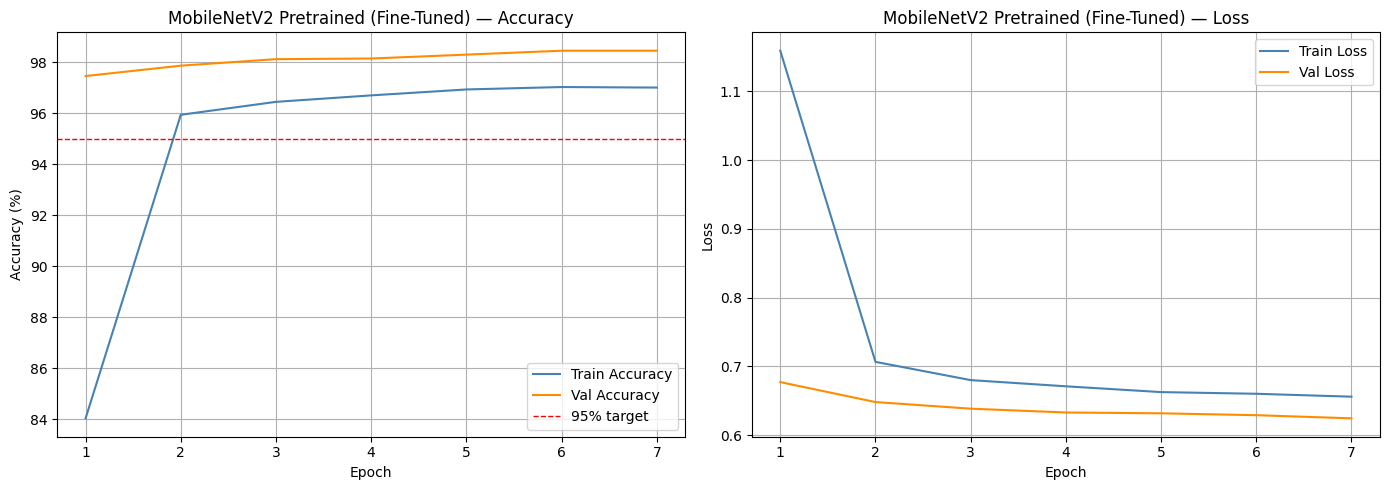

In [ ]:
history_pretrained = train_model(
    model_pretrained, train_loader, val_loader,
    criterion, optimizer_pt, scheduler_pt,
    epochs=10, early_stop_patience=2
)

plot_history(history_pretrained, title='MobileNetV2 Pretrained (Fine-Tuned)')

#### Evaluation

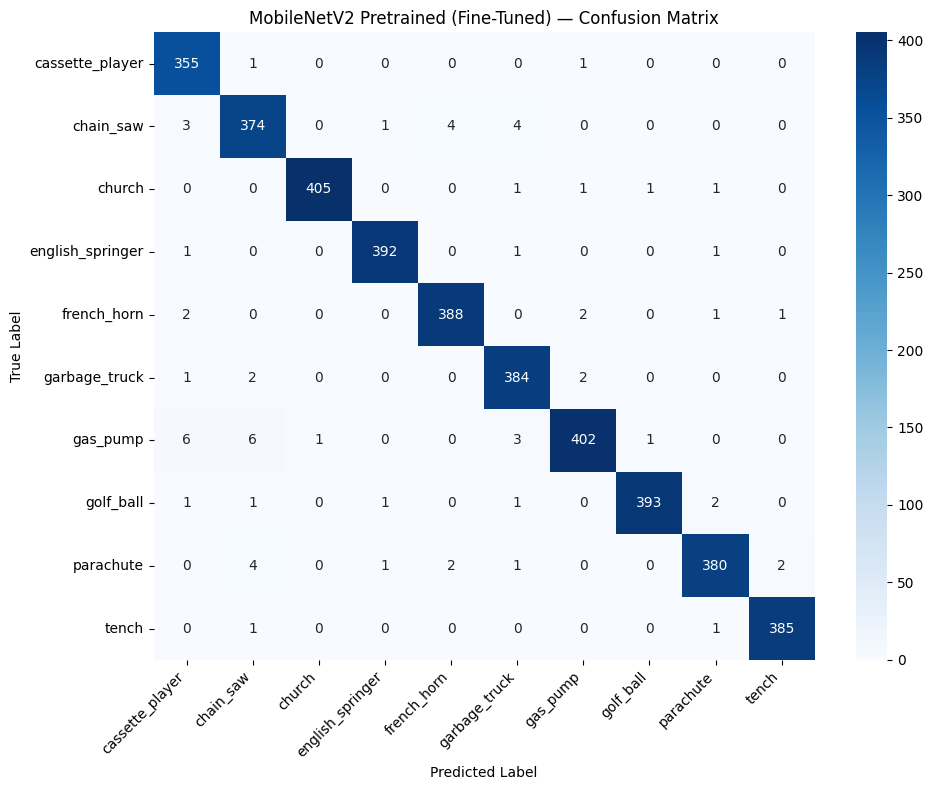


MobileNetV2 Pretrained (Fine-Tuned) — Classification Report

                  precision    recall  f1-score   support

 cassette_player       0.96      0.99      0.98       357
       chain_saw       0.96      0.97      0.97       386
          church       1.00      0.99      0.99       409
english_springer       0.99      0.99      0.99       395
     french_horn       0.98      0.98      0.98       394
   garbage_truck       0.97      0.99      0.98       389
        gas_pump       0.99      0.96      0.97       419
       golf_ball       0.99      0.98      0.99       399
       parachute       0.98      0.97      0.98       390
           tench       0.99      0.99      0.99       387

        accuracy                           0.98      3925
       macro avg       0.98      0.98      0.98      3925
    weighted avg       0.98      0.98      0.98      3925



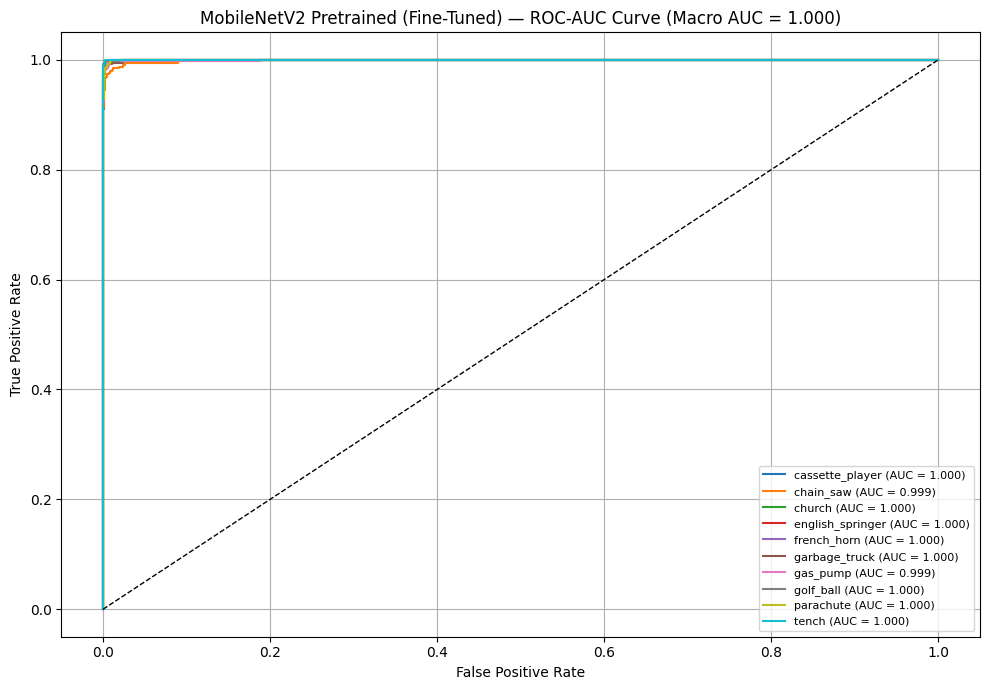

In [ ]:
labels_pt, preds_pt, probs_pt = evaluate_model(
    model_pretrained, val_loader, class_names, title='MobileNetV2 Pretrained (Fine-Tuned)'
)

Just like the ones in the Procedure, the pretrained model achieved the desired accuracy right from the start. However, its performance starts to plateau after a few more epochs, and early stopping helped prevent more time being spent for minimal gains.  

### Compare and Contrast the two models

Metric                       Scratch     Pretrained
Val Accuracy                  78.50%         98.29%
Macro ROC-AUC                 0.9685         0.9997
Epochs Trained                    37              7
Total Params                   ~3.4M          ~3.4M


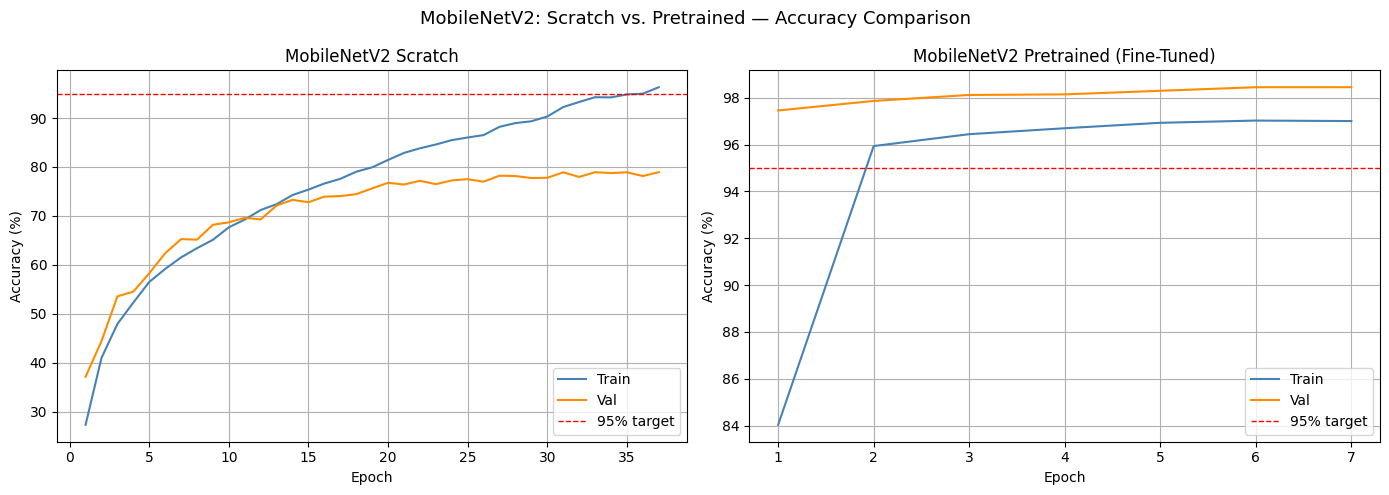

In [ ]:
from sklearn.metrics import accuracy_score

acc_scratch    = accuracy_score(labels_s,  preds_s)
acc_pretrained = accuracy_score(labels_pt, preds_pt)

labels_bin     = label_binarize(labels_s, classes=range(10))
auc_scratch    = roc_auc_score(labels_bin, probs_s,  average='macro', multi_class='ovr')
auc_pretrained = roc_auc_score(labels_bin, probs_pt, average='macro', multi_class='ovr')

# ── Summary Table ──────────────────────────────────────────────────────
print("=" * 52)
print(f"{'Metric':<25} {'Scratch':>10} {'Pretrained':>14}")
print("=" * 52)
print(f"{'Val Accuracy':<25} {acc_scratch*100:>9.2f}% {acc_pretrained*100:>13.2f}%")
print(f"{'Macro ROC-AUC':<25} {auc_scratch:>10.4f} {auc_pretrained:>14.4f}")
print(f"{'Epochs Trained':<25} {len(history_scratch['train_acc']):>10} {len(history_pretrained['train_acc']):>14}")
print(f"{'Total Params':<25} {'~3.4M':>10} {'~3.4M':>14}")
print("=" * 52)

# ── Side-by-side Accuracy Curves ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, history, label in zip(axes,
                               [history_scratch, history_pretrained],
                               ['Scratch', 'Pretrained (Fine-Tuned)']):
    epochs = range(1, len(history['train_acc']) + 1)
    ax.plot(epochs, [a*100 for a in history['train_acc']], label='Train', color='steelblue')
    ax.plot(epochs, [a*100 for a in history['val_acc']],   label='Val',   color='darkorange')
    ax.axhline(y=95, color='red', linestyle='--', linewidth=1, label='95% target')
    ax.set_title(f'MobileNetV2 {label}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.legend()
    ax.grid(True)

plt.suptitle('MobileNetV2: Scratch vs. Pretrained — Accuracy Comparison', fontsize=13)
plt.tight_layout()
plt.show()

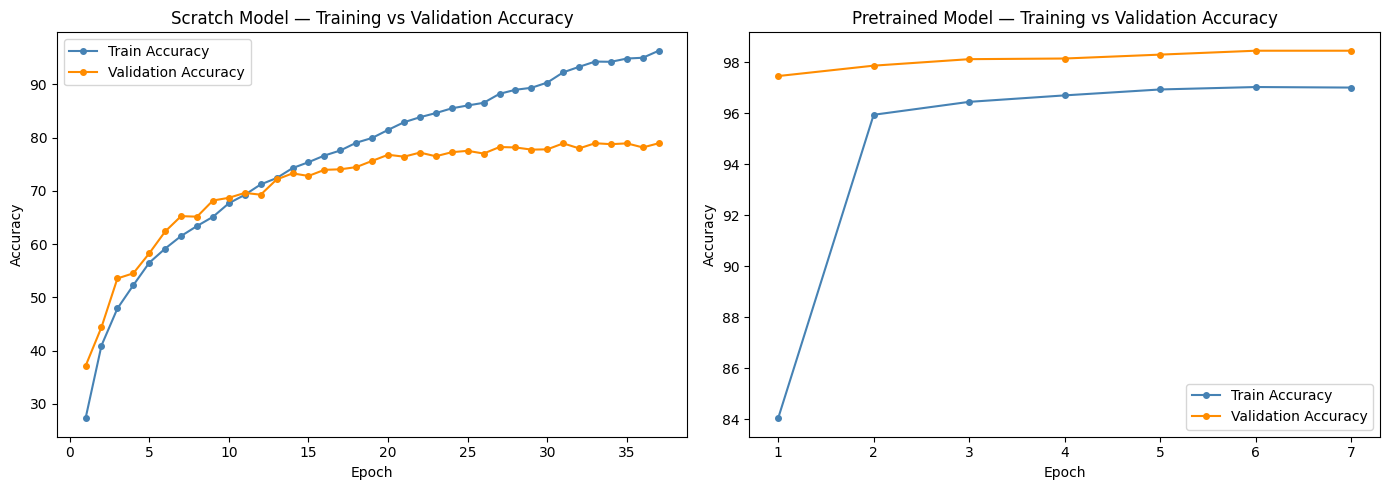

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, history, label in zip(axes,
                               [history_scratch, history_pretrained],
                               ['Scratch Model', 'Pretrained Model']):
    epochs = range(1, len(history['train_acc']) + 1)
    ax.plot(epochs, [a*100 for a in history['train_acc']],
            label='Train Accuracy', color='steelblue', marker='o', markersize=4)
    ax.plot(epochs, [a*100 for a in history['val_acc']],
            label='Validation Accuracy', color='darkorange', marker='o', markersize=4)
    ax.set_title(f'{label} — Training vs Validation Accuracy')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(False)

plt.tight_layout()
plt.show()

The graphs show the contrast between the pretrained models and models built from scratch, showing the advantage of pretrained models in terms of performance (accuracy). Another thing that wasn't seen in the graphs was the training it took for the models to reach their peak accuracies. Pretrained models still took less time to achieve better results.

# Conclusion

This activity taught me about the importance of pretrained models and transfer learning in tasks like classification. Transfer learning helps in making training a bit more easier and better, as all that's needed is a bit of finetuning in accordance to the task at hand, and it's good to go. In contrast with models trained from scratch, pretrained models offer scalability and speed in deploying deep learning models for various tasks.